In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv', index_col=0)

In [ ]:
# 컬럼 확인
print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'label'],
      dtype='object')


In [ ]:
# 레이블 분포 확인
print(df['label'].value_counts())

label
1    357
0    212
Name: count, dtype: int64


In [ ]:
# 결측치 확인
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64


In [ ]:
# 결측치 제거
df = df.dropna()

In [ ]:
# 입력(X), 정답(y) 분리
X = df.drop('label', axis=1)
y = df['label']

In [ ]:
# numpy 변환
X = X.values
y = y.values

In [ ]:
# train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

**손실함수**

• Binary Crossentropy

이 손실 함수는 이진 분류 문제(binary classification)에 사용된다. 모델은 두 개의 클래스 중 하나를 예측해야 하며, 정답은 일반적으로 0 또는 1의 형태로 표현된다.
이 경우 출력층에는 시그모이드(sigmoid) 활성화 함수를 사용한다. 시그모이드는 입력값을 0과 1 사이의 값으로 변환하여 특정 클래스(보통 1)에 속할 확률을 출력한다.

• Categorical Crossentropy

이 손실 함수는 다중 클래스 분류 문제(multi-class classification)에 사용된다. 모델은 세 개 이상의 클래스 중 하나를 선택해야 하며, 정답은 일반적으로 원-핫 인코딩(one-hot encoding) 형태로 표현된다. 출력층에는 소프트맥스(softmax) 활성화 함수를 사용하며, 이 함수는 각 클래스에 대한 확률 분포를 생성하고 전체 합이 1이 되도록 정규화한다.

In [ ]:
# 모델 정의
model = Sequential([
    Input(shape=(30,)),
    Dense(10, activation='relu'),
    Dense(8, activation='relu'),
    Dense(6, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459 (1.79 KB)

 Trainable params: 459 (1.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 학습
model_history = model.fit(
    x=X_train,
    y=y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6484 - loss: 0.9537 - val_accuracy: 0.6930 - val_loss: 0.5647
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7451 - loss: 0.6206 - val_accuracy: 0.7193 - val_loss: 0.4942
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7670 - loss: 0.5571 - val_accuracy: 0.8333 - val_loss: 0.5711
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8440 - loss: 0.4495 - val_accuracy: 0.8333 - val_loss: 0.5109
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8330 - loss: 0.4676 - val_accuracy: 0.8333 - val_loss: 0.4864
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8549 - loss: 0.4380 - val_accuracy: 0.8421 - val_loss: 0.3918
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8659 - loss: 0.3975 - val_accuracy: 0.8158 - val_loss: 0.3858
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8703 - loss: 0.3895 - val_accuracy: 0.8158 - val_lo

In [ ]:
# 예측
y_pred = model.predict(X_test)

# 확률 -> 0/1 클래스 변환
y_pred_class = (y_pred > 0.5).astype(int).reshape(-1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


**loss 그래프**

모델의 예측값과 실제값 사이의 오차를 나타내는 지표

 학습 과정에서 모델이 얼마나 잘못 예측하고 있는지를 수치적으로 보여주며, 값이 낮을수록 모델의 성능이 좋은 상태

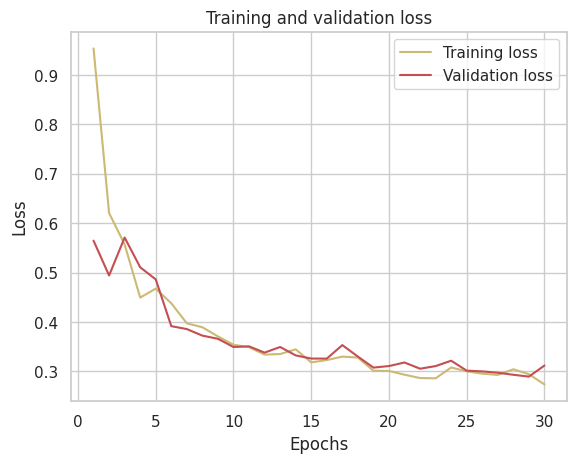

In [ ]:
# loss 그래프
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**accuracy 그래프**

학습 과정에서 모델이 데이터를 얼마나 정확하게 분류하는지를 나타내는 지표

epoch에 따라 학습 데이터의 정확도와 검증 데이터의 정확도 변화를 확인할 수 있는 값


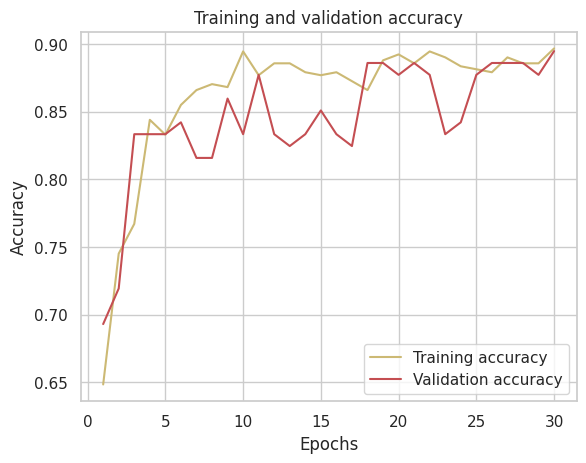

In [ ]:
# accuracy 그래프
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**모델 평가**

**classification_report:**

실제값(y_test)과 예측값(y_pred_class)을 비교하여
정밀도(precision), 재현율(recall), F1-score를 계산
모델이 각 클래스를 얼마나 정확하게 분류하는지 수치적으로 확인

**confusion_matrix:**

실제 클래스와 예측 클래스를 행렬 형태로 출력
행: 실제값, 열: 예측값
어떤 클래스를 맞췄는지 / 어디서 틀렸는지 직관적으로 분석 가능

In [ ]:
print(classification_report(y_test, y_pred_class))
print(confusion_matrix(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.97      0.77      0.86        47
           1       0.86      0.99      0.92        67

    accuracy                           0.89       114
   macro avg       0.92      0.88      0.89       114
weighted avg       0.90      0.89      0.89       114

[[36 11]
 [ 1 66]]
